In [4]:
####################################
# Set env vars
####################################
import os
from pathlib import Path

# Resolve path two levels up from where the notebook is running
SCRATCH_HOME = Path.cwd().resolve().parent
os.environ["SCRATCH_HOME"] = str(SCRATCH_HOME)
print(os.getenv("SCRATCH_HOME"))


/home/sam/repos/hobby-repos/scratch-ml


In [5]:
####################################
# Load data
####################################
import pandas as pd
df = pd.read_csv(os.path.join(os.getenv("SCRATCH_HOME"), "data", "input", "data_signals.csv"))
df.head()

,time,sine,square,triangle,target
0,0.00,3.115180,4.402571,1.219599,2.693661
1,0.01,3.114040,4.483482,1.420926,2.701945
2,0.02,3.341529,4.384695,1.494317,2.791983
3,0.03,3.582628,4.458562,1.633940,2.898274
4,0.04,3.398221,4.216793,1.398763,2.939928


In [6]:
####################################
# Check total amount of samples
####################################
print(len(df))

2000


In [7]:
####################################
# Assign data to x and y and split
####################################
import numpy as np

# Assign time series data
x = df[['sine', 'square', 'triangle']].to_numpy(dtype=np.float32)
y = df[['target']].to_numpy(dtype=np.float32)

# Splittys (but since it's time series we don't need anything extra here)
train_end = int(0.6 * len(df))
x_train, x_val = x[:train_end, :], x[train_end:, :]
y_train, y_val = y[:train_end, :], y[train_end:, :]

print(f"x_train shape is {x_train.shape}")
print(f"y_train shape is {y_train.shape}")

x_train shape is (1200, 3)
y_train shape is (1200, 1)


In [8]:
####################################
# Scale x data (with a scaler only created via x train)
####################################
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(x_train) # We want to scale only on training data to avoid leakage
x_train_scaled_np = scaler.transform(x_train)
x_val_scaled_np   = scaler.transform(x_val)

In [9]:
####################################
# Make windows and convert data to torch
####################################
import numpy as np
import torch

def make_windows(x, y, lookback: int, horizon: int = 1, stride: int = 1, as_torch: bool = True):
    """
    Build sliding windows for sequence models.

    Args:
        x: np.ndarray of shape (T, x_dim)
        y: np.ndarray of shape (T,) or (T, y_dim)
        lookback: number of past steps per input window
        horizon: number of future steps to predict (default: 1 = next-step)
        stride: shift between consecutive windows (default: 1)
        as_torch: if True, return torch.float32 tensors, else numpy arrays

    Returns:
        X: (N of windows (batches), lookback, x_features)
        Y: (N of windows, y_features) if horizon==1 else (N of windows, horizon, y_features)

    Notes:
        - No shuffling; preserves time order (good for forecasting).
        - No leakage: each target window starts exactly after each input window.
        - Number of windows (or batches) is N = ((total number of samples - lookback - horizon)/stride) + 1
    """
    x = np.asarray(x)
    y = np.asarray(y)

    if y.ndim == 1:
        y = y.reshape(-1, 1)

    T = x.shape[0]
    x_dim = x.shape[1]
    y_dim = y.shape[1]

    max_start = T - lookback - horizon + 1
    if max_start <= 0:
        raise ValueError(f"Not enough timesteps: T={T}, lookback={lookback}, horizon={horizon}")

    X_list, Y_list = [], []
    for start in range(0, max_start, stride):
        end = start + lookback
        tgt_end = end + horizon
        X_list.append(x[start:end])           # (lookback, x_dim)
        Y_list.append(y[end:tgt_end])         # (horizon, y_dim)

    X = np.stack(X_list, axis=0)              # (N, lookback, x_dim)
    Y = np.stack(Y_list, axis=0)              # (N, horizon, y_dim)

    if horizon == 1:
        Y = Y[:, 0, :]                        # (N, y_dim)

    if as_torch:
        X = torch.from_numpy(X).to(torch.float32)
        Y = torch.from_numpy(Y).to(torch.float32)

    return X, Y

lookback = 256
x_seq_train_torch, y_seq_train_torch = make_windows(x_train_scaled_np, y_train, lookback=lookback, horizon=1, stride=1, as_torch=True)
x_seq_val_torch, y_seq_val_torch = make_windows(x_val_scaled_np, y_val, lookback=lookback, horizon=1, stride=1, as_torch=True)
print(f"x_seq_train shape is {x_seq_train_torch.shape}")
print(f"y_seq_train shape is {x_seq_val_torch.shape}")

x_seq_train shape is torch.Size([944, 256, 3])
y_seq_train shape is torch.Size([544, 256, 3])


In [10]:
####################################
# Create data loaders
####################################
from torch.utils.data import TensorDataset, DataLoader

# Set seeds
base_seed = 42
np.random.seed(base_seed)
torch.manual_seed(base_seed)
g = torch.Generator()    # Creates a generator that fixes the shuffle in torch Dataloader
g.manual_seed(base_seed)

# Create data loaders for batching
train_loader = DataLoader(
    TensorDataset(x_seq_train_torch, y_seq_train_torch),
    batch_size=64,
    shuffle=True,                       # We want random mini batches so GD doesn't overfit to specific ordering patterns, lets shuffle
    generator=g,                        # Fixes the shuffle
    num_workers=0,                      # Eliminate worker non-determinism
    pin_memory=True,                    # Batches are allocated on page-locked ("pinned") memory on the host, allows GPU driver to perform faster async DMA
    )  

val_loader = DataLoader(
    TensorDataset(x_seq_val_torch, y_seq_val_torch),
    batch_size=64,
    shuffle=False,                      # In eval we aren't updating the weights, so it doesn't really matter if we imply ordering or not
    num_workers=0,                      # Eliminate worker non-determinism
    pin_memory=True,                    # Batches are allocated on page-locked ("pinned") memory on the host, allows GPU driver to perform faster async DMA
    )

In [11]:
####################################
# Create LSTM model
####################################
import torch.nn as nn

class LSTMRegressor(nn.Module):
    def __init__(self, input_size: int, hidden_size: int = 64, num_layers: int = 1, dropout: float = 0.0):
        super().__init__()
        # LSTM reads a sequence of vectors (len = T, dim = input_size) and produces a sequence of hidden states (dim = hidden_size)
        # B = batch size or number of windows
        # T = samples in a batch/window
        # F = feature dimension
        self.lstm = nn.LSTM(
            input_size=input_size,        # features per timestep, F
            hidden_size=hidden_size,      # size of LSTM hidden state, H
            num_layers=num_layers,        # stack depth: 1..N LSTM layers
            dropout=dropout if num_layers > 1 else 0.0,  # dropout *between* stacked layers
            batch_first=True,             # expect x shaped (B, T, F) instead of (T, B, F)
        )
        # Final linear head maps the LAST timestep's hidden state (H) → scalar target (1)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (B, T, F)
        out, (h_n, c_n) = self.lstm(x)
        # out: (B, T, H)  hidden states for every timestep
        # h_n: (num_layers, B, H) final hidden state per layer (top layer is h_n[-1])
        # c_n: (num_layers, B, H) final cell state per layer (not used here)

        last = out[:, -1, :]             # take the hidden state at the final timestep: (B, H)
        yhat = self.head(last)           # project to scalar: (B, 1)
        return yhat

In [12]:
####################################
# Define model and loss
####################################
import torch.optim as optim
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMRegressor(input_size=3, hidden_size=32, num_layers=2, dropout=0.1).to(device)
optimizer = optim.Adam(model.parameters())
criterion = nn.MSELoss()

print(f"Model is {model} running on {device}")

Model is LSTMRegressor(
  (lstm): LSTM(3, 32, num_layers=2, batch_first=True, dropout=0.1)
  (head): Linear(in_features=32, out_features=1, bias=True)
) running on cuda


In [13]:
####################################
# Training
####################################
epochs = 500
best_val = float("inf")
best_state = None
train_rmse_hist, val_rmse_hist = [], []

for epoch in range(1, epochs + 1):
    ################
    # Training
    ################
    model.train()                   # Setting some dropout layers to go to 0 to prevent overfitting & normalize activations of previous layer
    train_loss_sum = 0.0            # For each epoch we want to zero out the training loss since we are starting fresh on the dataset
    n = 0              
    for xb, yb in train_loader:
        xb = xb.to(device, non_blocking=True)   # non_blocking allows CPU to to continue exec'ing code while data transfer to GPU goes concurrently (requires CPU pinned memory)
        yb = yb.to(device, non_blocking=True)
        optimizer.zero_grad()       # For each batch we compute loss and take the gradient of that to update model weights, then make a model update, so zero out gradients from prior batch
        preds = model(xb)           # Forward pass of predictions, this does the call forward fcn
        loss = criterion(preds, yb) # Computes loss of predictions vs actuals, this is the average loss over the batch
        loss.backward()             # Backpropagation, computes gradients of loss w.r.t. each model parameter and stores in param.grad
        #torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()            # Reads gradients and updates model params based on optimizer config (learning rate, etc)
        train_loss_sum += loss.item() * xb.size(0)  # Want the sum of loss over samples, because at end of training we divide by total samples to get exact dataset loss, even when last batch may not be exactly batch size
        n += xb.size(0)             # We want to record number of batches we went through, since we may decide to break out early or something
    train_loss = train_loss_sum / n  # We divide the accumualted loss for the batch by the number of batches we actually got through

    ################
    # Validation
    ################
    model.eval()                   # Disable droput layers and activation normalization
    val_loss_sum = 0.0             # Zero out validation loss for each epoch
    n = 0
    with torch.no_grad():          # We aren't updating weights, so we don't need to compute gradients, this saves memory and computations
        for xb, yb in val_loader:
            xb = xb.to(device, non_blocking=True)  # non_blocking allows CPU to to continue exec'ing code while data transfer to GPU goes concurrently (requires CPU pinned memory)
            yb = yb.to(device, non_blocking=True)
            preds = model(xb)
            loss = criterion(preds, yb)
            val_loss_sum += loss.item() * xb.size(0)
            n += xb.size(0) # We want to record number of batches we went through, since we may decide to break out early or somethin
    val_loss = val_loss_sum / n  # We divide the accumualted loss for the batch by the number of batches we actually got through

    # Create performance metrics
    train_rmse = float(np.sqrt(train_loss))
    val_rmse   = float(np.sqrt(val_loss))
    train_rmse_hist.append(train_rmse)
    val_rmse_hist.append(val_rmse)

    # Record best state
    if val_rmse < best_val:
        best_val = val_rmse
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:02d} | train RMSE: {train_rmse:.6f} | val RMSE: {val_rmse:.6f}")

# restore best
if best_state is not None:
    model.load_state_dict(best_state)

Epoch 10 | train RMSE: 0.577876 | val RMSE: 0.503084
Epoch 20 | train RMSE: 0.326791 | val RMSE: 0.305555
Epoch 30 | train RMSE: 0.313448 | val RMSE: 0.299435
Epoch 40 | train RMSE: 0.307816 | val RMSE: 0.294208
Epoch 50 | train RMSE: 0.308836 | val RMSE: 0.295520
Epoch 60 | train RMSE: 0.298665 | val RMSE: 0.288993
Epoch 70 | train RMSE: 0.294101 | val RMSE: 0.287800
Epoch 80 | train RMSE: 0.303582 | val RMSE: 0.286976
Epoch 90 | train RMSE: 0.294202 | val RMSE: 0.282763
Epoch 100 | train RMSE: 0.291888 | val RMSE: 0.283522
Epoch 110 | train RMSE: 0.291299 | val RMSE: 0.285106
Epoch 120 | train RMSE: 0.291895 | val RMSE: 0.281945
Epoch 130 | train RMSE: 0.285677 | val RMSE: 0.290871
Epoch 140 | train RMSE: 0.288595 | val RMSE: 0.283725
Epoch 150 | train RMSE: 0.285743 | val RMSE: 0.281973
Epoch 160 | train RMSE: 0.287339 | val RMSE: 0.284977
Epoch 170 | train RMSE: 0.279916 | val RMSE: 0.286249
Epoch 180 | train RMSE: 0.279295 | val RMSE: 0.284887
Epoch 190 | train RMSE: 0.291398 | va

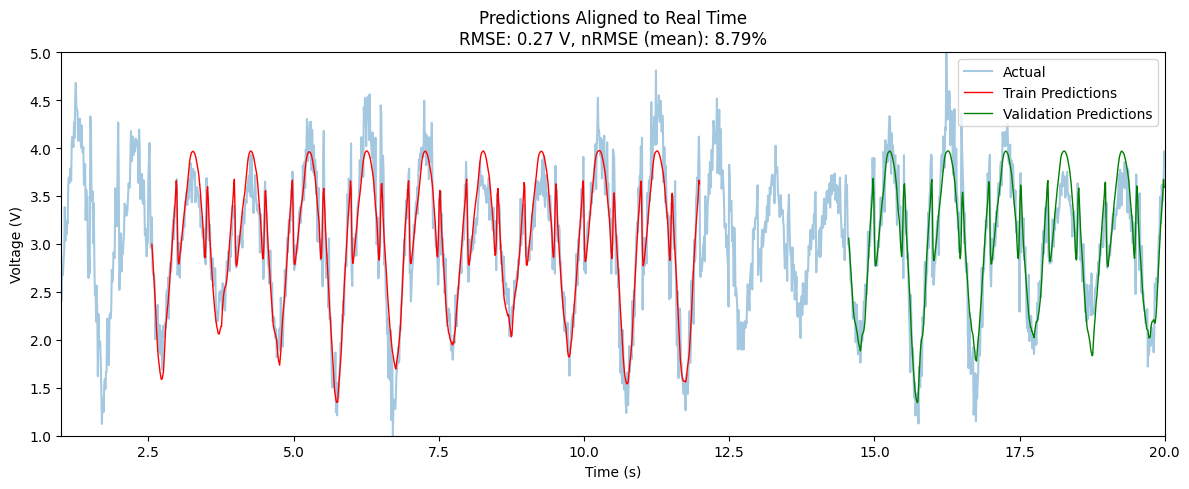

In [14]:
####################################
# Plotting
####################################
import matplotlib.pyplot as plt

@torch.no_grad()
def predict_ordered_windows(model, X, device):
    model.eval()
    # If large, do mini-batches; for small, one shot is fine:
    X = X.to(device)

    # NOTE:
    # Squeeze removes the dimensions of size 1 so goes from (N, 1) --> (N,)
    # Detach makes a new tensor that does not have gradient info
    # CPU moves it from a CUDA tensor to cpu mem
    # Converts back to numpy
    yhat = model(X).squeeze(-1).detach().cpu().numpy()  # (N,) 
    return yhat

# Get predictions in chronological (non-shuffled) order
yhat_train = predict_ordered_windows(model, x_seq_train_torch, device)  # (N_tr,)
yhat_val   = predict_ordered_windows(model, x_seq_val_torch, device)    # (N_va,)

# Map window-indexed predictions to absolute time indices
time = df["time"]
T = len(time)           # total samples
N_tr = len(yhat_train)  # training prediction count
N_va = len(yhat_val)    # validation prediction count

# For horizon=1, each window predicts the sample right after the window:
# train windows cover indices [0 .. train_end-1], so their targets are at:
t_idx_train = np.arange(lookback, lookback + N_tr)                  # absolute:  lookback .. train_end-1
# val windows are built on the val segment, so offset by train_end:
t_idx_val   = train_end + np.arange(lookback, lookback + N_va)      # absolute:  train_end+lookback .. T-1

# Determine normalized RMSE (by mean)
nRMSE = (best_val / df["target"].mean()) * 100

# Plot against the real time axis
y_plot = df["target"]
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(time, y_plot, label="Actual", linewidth=1.5, alpha=0.4)                       # blue by default
ax.plot(time[t_idx_train], yhat_train, label="Train Predictions", linewidth=1.0, color="red")
ax.plot(time[t_idx_val],   yhat_val,   label="Validation Predictions",   linewidth=1.0, color="green")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Voltage (V)")
ax.set_xlim(1, 20)
ax.set_ylim(1, 5)
ax.set_title(f"Predictions Aligned to Real Time\nRMSE: {round(best_val, 2)} V, nRMSE (mean): {round(nRMSE, 2)}%")
ax.legend()
plt.tight_layout()
plt.show()
